[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch05-simple_workbook.ipynb)

# `darcy`, and the `darcy` before it

In Pride and Prejudice a name comes back after a gap of many words. A
recurrent network that links the two uses sends a learning signal back
across the gap, and every word multiplies it by a factor below 1. How much of
it arrives?

In [1]:
#@title Setup: run this cell first
import math
import os
import re
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# A gap counts as crossed when one per cent of the signal is left at its far end. A word needs 10
# uses for its gaps to be counted.
ONE_PER_CENT, MIN_USES = 0.01, 10
plt.rcParams.update({"xtick.labelsize": 8, "ytick.labelsize": 8})


class Refused(Exception):  # a setting a cell refuses: Colab prints the one sentence, without the stack
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


CHAPTERS = load_novel()
TOKENS = [w for chapter in CHAPTERS for w in chapter]
POSITIONS = {}
for p, w in enumerate(TOKENS):
    POSITIONS.setdefault(w, []).append(p)


# Step 1: the gaps of a word, the number of words from each use back to the use before it.
def gaps(word):
    w = word.strip().lower() if isinstance(word, str) else word
    if w not in POSITIONS or len(POSITIONS[w]) < MIN_USES:
        raise Refused(f"WORD is {word!r}: WORD takes a word the novel uses at least {MIN_USES} times, such as darcy.")
    return w, np.diff(POSITIONS[w])


def reach(factor):  # the gap at which one per cent of the signal is left: factor ** reach = 0.01
    return math.log(ONE_PER_CENT) / math.log(factor)


def gate(name, x):
    if type(x) not in (int, float) or not 0 < x < 1:
        raise Refused(f"{name} is {x!r}: {name} takes a number above 0 and below 1.")
    return float(x)


def histogram(w, g, lines, title):  # the gaps on a log axis, one vertical line per (label, gap, colour)
    fig, ax = plt.subplots(figsize=(6, 2.8), layout="constrained")
    ax.hist(g, bins=np.logspace(0, math.log10(g.max() + 1), 30), color="0.75")
    for label, x, colour in lines:
        ax.axvline(x, color=colour, lw=1.6, label=label)
    ax.set(xscale="log", xlabel="gap in words, log scale", ylabel="gaps", title=title)
    if lines:
        ax.legend(fontsize=8)
    plt.show()


def show_gaps(word):
    w, g = gaps(word)
    print(f"{w}: {len(g) + 1} uses, {len(g)} gaps; median gap {np.median(g):.0f} words; "
          f"{np.mean(g <= 20):.1%} of the gaps are 20 words or fewer")
    histogram(w, g, [(f"median, {np.median(g):.0f} words", np.median(g), "C0")], f"gaps between two uses of {w}")


# Steps 2 and 3: a gap keeps one per cent or more of the signal when it is shorter than the reach.
def across(word, *factors):
    w, g = gaps(word)
    lines = []
    for name, f, colour in zip(("FACTOR", "FORGET"), factors, ("C3", "C2")):
        f = gate(name, f)
        print(f"{name} {f:g}: one per cent of the signal is left after {reach(f):.0f} words; "
              f"{np.mean(f ** g >= ONE_PER_CENT):.1%} of the {len(g)} gaps of {w} keep more")
        lines.append((f"{f:g} per word: one per cent at {reach(f):.0f}", reach(f), colour))
    histogram(w, g, lines, f"gaps of {w} and the reach of the signal")


# Appendix: training cuts the gradient every BPTT words, whatever the gate.
def cut(word, bptt):
    if type(bptt) is not int or not 1 <= bptt <= 1000:
        raise Refused(f"BPTT is {bptt!r}: BPTT takes a whole number from 1 to 1000.")
    w, g = gaps(word)
    print(f"cut every {bptt} words: {np.mean(g > bptt):.1%} of the {len(g)} gaps of {w} are longer")
    histogram(w, g, [(f"cut at {bptt} words", bptt, "C1")], f"gaps of {w} and the training cut")


display(Markdown(f"The novel: {len(TOKENS):,} tokens in {len(CHAPTERS)} chapters; `darcy` is used {len(POSITIONS['darcy'])} times."))

The novel: 122,174 tokens in 61 chapters; `darcy` is used 374 times.

## 1. Gaps between two uses of a name

For each use of `WORD` after the first, the cell counts the words back to the
use before it, and draws how many gaps have each length. Run the cell for
`darcy`: how long is a typical gap? Then set `WORD` to `elizabeth` and to
`she`, and run it again.

darcy: 374 uses, 373 gaps; median gap 142 words; 6.4% of the gaps are 20 words or fewer


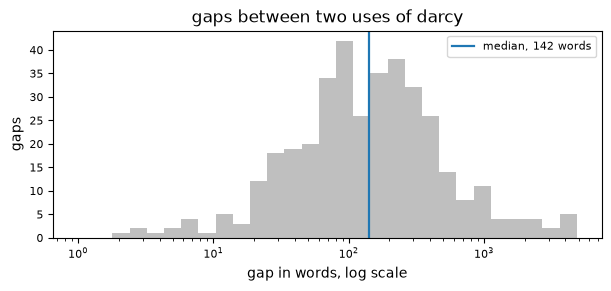

In [2]:
WORD = "darcy"
show_gaps(WORD)

### Solution

In [3]:
med = {x: np.median(gaps(x)[1]) for x in ("darcy", "elizabeth", "she")}
short = np.mean(gaps("darcy")[1] <= 20)
display(Markdown(f"Half the gaps of `darcy` are longer than {med['darcy']:.0f} words, and {short:.1%} are 20 words or fewer. "
                 f"`elizabeth` comes back after a median {med['elizabeth']:.0f} words and `she` after {med['she']:.0f}."))

Half the gaps of `darcy` are longer than 142 words, and 6.4% are 20 words or fewer. `elizabeth` comes back after a median 127 words and `she` after 30.

## 2. The signal a plain network sends across each gap

A plain recurrent network multiplies the learning signal by about `FACTOR`
at every word it is sent back. The red line marks the gap at which one per
cent of the signal is left; gaps to its left keep more. Run the cell, then
set `FACTOR` to 0.9 and run it again.

FACTOR 0.8: one per cent of the signal is left after 21 words; 6.4% of the 373 gaps of darcy keep more


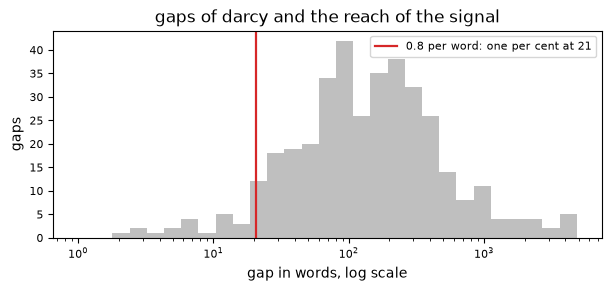

In [4]:
FACTOR = 0.8
across(WORD, FACTOR)

### Solution

In [5]:
g = gaps("darcy")[1]
kept = {f: np.mean(f ** g >= ONE_PER_CENT) for f in (0.8, 0.9)}
display(Markdown(f"At 0.8 per word one per cent of the signal is left after {reach(0.8):.0f} words, and {kept[0.8]:.1%} of the gaps "
                 f"of `darcy` keep more; at 0.9 the reach is {reach(0.9):.0f} words and {kept[0.9]:.1%}. At 0.8, {1 - kept[0.8]:.1%} of the "
                 "uses of the name get less than one per cent of the signal from the use before."))

At 0.8 per word one per cent of the signal is left after 21 words, and 6.4% of the gaps of `darcy` keep more; at 0.9 the reach is 44 words and 17.4%. At 0.8, 93.6% of the uses of the name get less than one per cent of the signal from the use before.

## 3. A forget gate across the same gaps

Along an LSTM's cell state the signal is multiplied by the forget gate
`FORGET` alone. Run the cell to compare a forget gate of 0.95 with the plain
network's `FACTOR`. Then set `FORGET` to 0.99 and run it again.

FACTOR 0.8: one per cent of the signal is left after 21 words; 6.4% of the 373 gaps of darcy keep more
FORGET 0.95: one per cent of the signal is left after 90 words; 35.9% of the 373 gaps of darcy keep more


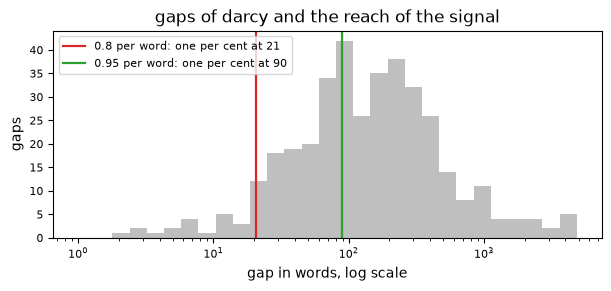

In [6]:
FORGET = 0.95
across(WORD, FACTOR, FORGET)

### Solution

In [7]:
kept = {f: np.mean(f ** g >= ONE_PER_CENT) for f in (0.8, 0.95, 0.99)}
display(Markdown(f"A forget gate of 0.95 keeps one per cent over {reach(0.95):.0f} words, and {kept[0.95]:.1%} of the gaps of `darcy` "
                 f"are shorter, against {kept[0.8]:.1%} for the plain network; at 0.99 the reach is {reach(0.99):.0f} words and "
                 f"{kept[0.99]:.1%} of the gaps. The gate sets the reach, and a gate near 1 reaches most of the name's gaps."))

A forget gate of 0.95 keeps one per cent over 90 words, and 35.9% of the gaps of `darcy` are shorter, against 6.4% for the plain network; at 0.99 the reach is 458 words and 86.1% of the gaps. The gate sets the reach, and a gate near 1 reaches most of the name's gaps.

## Appendix. The training cut

The signal left after a gap of g words at a factor f is f to the power g, and
one per cent is left at g = ln 0.01 / ln f.

Training stops the gradient at a boundary every `BPTT` words, whatever the
gate: truncated backpropagation through time. The course's networks cut every
35 words, as Zaremba, Sutskever and Vinyals did. A gap longer than the cut
trains nothing, however near 1 the forget gate is. The chart marks the cut
on the gaps of `darcy`.

cut every 35 words: 86.1% of the 373 gaps of darcy are longer


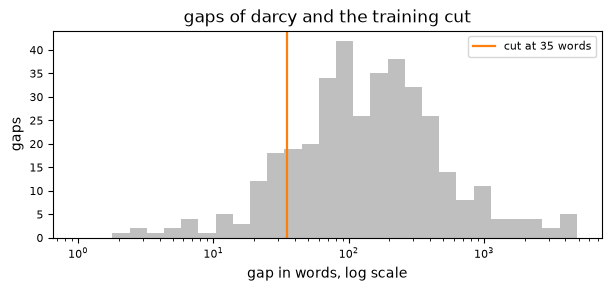

In [8]:
cut("darcy", 35)

**Exercise.** Set `BPTT` to 100 and then `WORD` to `she`, and rerun the
cell. What share of the gaps is longer than the cut each time?

cut every 35 words: 86.1% of the 373 gaps of darcy are longer


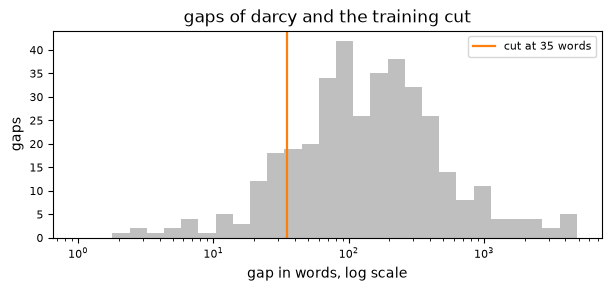

In [9]:
WORD, BPTT = "darcy", 35
cut(WORD, BPTT)

### Solution

In [10]:
longer = {(x, b): np.mean(gaps(x)[1] > b) for x in ("darcy", "she") for b in (35, 100)}
display(Markdown(f"Cut every 35 words, {longer['darcy', 35]:.1%} of the gaps of `darcy` are longer, and no forget gate trains the "
                 f"network across them; cut every 100, {longer['darcy', 100]:.1%}. `she` comes back sooner: {longer['she', 35]:.1%} "
                 f"of its gaps are longer than 35 words and {longer['she', 100]:.1%} longer than 100."))

Cut every 35 words, 86.1% of the gaps of `darcy` are longer, and no forget gate trains the network across them; cut every 100, 59.0%. `she` comes back sooner: 45.0% of its gaps are longer than 35 words and 18.7% longer than 100.